In [7]:
#Traffic PINN 1D test
#Check point 
#Import libraries



In [8]:
import numpy as np
import matplotlib.pyplot as plt
#import tensorflow as tf


In [9]:
# Craete 2D mesh Grid
#1. initialise x array
#2. initialise t array
#3. use meshgrid to create 2D mesh
N_x = 200
start_length = 0
end_length = 10 #(km)
N_t = 500
start_time = 0
end_time = 0.25#(hr)



arr_x = np.linspace(start_length, end_length, N_x)
arr_t = np.linspace(start_time, end_time, N_t)

X_grid, T_grid = np.meshgrid(arr_x, arr_t)
print (X_grid, T_grid)
#plot grid

[[ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 ...
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]
 [ 0.          0.05025126  0.10050251 ...  9.89949749  9.94974874
  10.        ]] [[0.       0.       0.       ... 0.       0.       0.      ]
 [0.000501 0.000501 0.000501 ... 0.000501 0.000501 0.000501]
 [0.001002 0.001002 0.001002 ... 0.001002 0.001002 0.001002]
 ...
 [0.248998 0.248998 0.248998 ... 0.248998 0.248998 0.248998]
 [0.249499 0.249499 0.249499 ... 0.249499 0.249499 0.249499]
 [0.25     0.25     0.25     ... 0.25     0.25     0.25    ]]


In [10]:
# 1. Base traffic density of 30 everywhere along the 200 spatial points
rho_0 = np.ones(N_x) * 30.0 #30vehicles /km
# 2. Define the traffic jam bump parameters
amplitude = 90.0  # Spikes the density from 30 up to 120 (30 + 90 = 120)
center = 4.0      # Centered at x = 4 km
spread = 1.0      # How wide the traffic jam stretches

# 3. Add the bell-shaped traffic jam to our baseline
# np.exp() computes e^x. When arr_x is exactly at the center (4.0), 
# this exponential term equals 1, giving us our maximum peak.
rho_0 += amplitude * np.exp(-((arr_x - center) / spread)**2)

print(rho_0)



[ 30.00001013  30.0000151   30.0000224   30.00003307  30.00004857
  30.00007097  30.00010318  30.00014926  30.00021482  30.00030762
  30.0004383   30.00062134  30.00087639  30.00122991  30.00171733
  30.00238583  30.00329787  30.00453559  30.00620642  30.00844997
  30.01144657  30.01542775  30.02068885  30.02760429  30.03664575
  30.04840355  30.06361178  30.08317724  30.10821266  30.14007425
  30.1804036   30.23117387  30.2947399   30.37389165  30.47191008
  30.5926242   30.74046778  30.92053351  31.13862229  31.4012848
  31.71585186  32.09045016  32.53399932  33.05618626  33.66741277
  34.37871235  35.20163277  36.1480814   37.23013121  38.4597864
  39.84870809  41.40790201  43.14737189  45.07574427  47.19987241
  49.52442882  52.05149808  54.78018298  57.70623847  60.82174875
  64.11486309  67.56960582  71.16577473  74.87894062  78.68055817
  82.53819531  86.41588443  90.2745949   94.07282141  97.76727857
 101.31368713 104.66763335 107.78547893 110.62529613 113.14780032
 115.3172512

In [11]:
v_max = 100.0
rho_max = 150.0

def traffic_flow(rho):
    
    return v_max * rho * (1.0 - rho / rho_max)

In [12]:
# numerical schemes 
#lax fredrichs
#1. initialise a rho_history to store old data this should be a (t,x) grid not (x, t) as we need it to match matrix multiplications

rho_history = np.zeros((N_t, N_x))



# for t=0, the rho history rom should be rho_0
rho_history[0,:] = rho_0

#print (rho_history)

#Define dx(delta x) since total length is 10km, and number of intervals are 200 (starting from 0) so intervals are 199
dx = end_length/ (N_x-1)
#similarly Dt delta t is end time/ interval 500-1 = 499
dt = end_time/(N_t-1)
print (dx)
print (dt)

CFL = v_max *(dt/(2*dx))

print (CFL)

####
# Loop through time steps
for n in range(0, N_t - 1):
    
    # 1. Create our blank array for the next step
    rho_next = np.zeros(N_x)
    #as per lax fredrichs rule we are trying to calculate the value of the ith term wuing i+1 and i-1
    # 2. Fill in the middle parts
    for i in range(1, N_x - 1):
        avg_density = 0.5 * (rho_history[n, i+1] + rho_history[n, i-1]) # this help smooth out the sudden shock
        
        # 2. Get the traffic flow at the right and left neighbors
        # (Using the flow equation you already built)
        q_right = traffic_flow(rho_history[n, i+1])
        q_left  = traffic_flow(rho_history[n, i-1])
        
        # 3. Compute the change in flow
        flow_change = (dt / (2 * dx)) * (q_right - q_left)
        
        # 4. Save the result for this spot
        rho_next[i] = avg_density - flow_change
        
    # 3. Fill in the edges of our whiteboard (constant boundaries)
    rho_next[0] = rho_history[n, 0]
    rho_next[-1] = rho_history[n, -1]
    
    # 4. Save this finished whiteboard into the history album!
    rho_history[n+1, :] = rho_next
    


0.05025125628140704
0.000501002004008016
0.49849699398797587


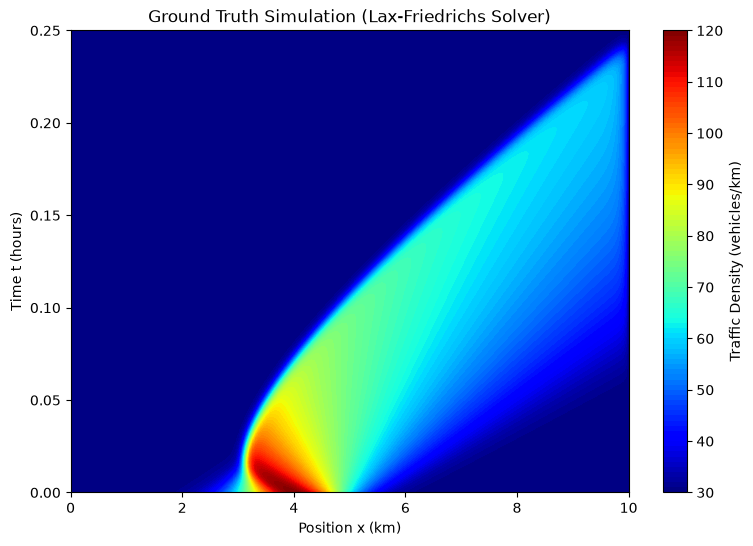

In [13]:
# 1. Create a figure
plt.figure(figsize=(9, 6))

# 2. Use contourf to plot the space-time density
# we use X_grid and T_grid that you made earlier with meshgrid!
contour = plt.contourf(X_grid, T_grid, rho_history, levels=100, cmap='jet')

# 3. Add labels and styling
plt.colorbar(contour, label='Traffic Density (vehicles/km)')
plt.xlabel('Position x (km)')
plt.ylabel('Time t (hours)')
plt.title('Ground Truth Simulation (Lax-Friedrichs Solver)')

# 4. Show the plot
plt.show()

In [14]:
#PINN architecture


# input nodes - 2 x and t 
# output nodes - 1 rho(x,t)
# hidden layers - 4 (initial)

#AI was used for this

import torch
import torch.nn as nn

# We inherit from nn.Module, which is PyTorch's base class for all neural networks
class TrafficPINN(nn.Module):
    def __init__(self):
        super(TrafficPINN, self).__init__()
        
        # 1. Define the layers
        # Input layer: Takes 2 inputs (x and t) and outputs 64 features
        self.input_layer = nn.Linear(2, 64)
        
        # Hidden layers: We use 3 intermediate layers to process the features
        self.hidden1 = nn.Linear(64, 64)
        self.hidden2 = nn.Linear(64, 64)
        self.hidden3 = nn.Linear(64, 64)
        
        # Output layer: Takes 64 features and collapses them to 1 output (rho)
        self.output_layer = nn.Linear(64, 1)
        
        # 2. Define our activation function
        # We use Tanh (hyperbolic tangent) because it is smooth and twice-differentiable.
        # This is mandatory for PINNs because we need to calculate smooth derivatives.
        self.activation = nn.Tanh()

    def forward(self, x_and_t):
        # This method defines how data flows through the network.
        # Input: 'x_and_t' is a tensor of shape [Batch_Size, 2] containing coordinates (x, t)
        
        # Pass through input layer and apply activation
        out = self.activation(self.input_layer(x_and_t))
        
        # Pass through hidden layers
        out = self.activation(self.hidden1(out))
        out = self.activation(self.hidden2(out))
        out = self.activation(self.hidden3(out))
        
        # Pass through output layer (No activation function at the very end!)
        rho_prediction = self.output_layer(out)
        
        return rho_prediction




In [15]:
model = TrafficPINN()
print(model)

TrafficPINN(
  (input_layer): Linear(in_features=2, out_features=64, bias=True)
  (hidden1): Linear(in_features=64, out_features=64, bias=True)
  (hidden2): Linear(in_features=64, out_features=64, bias=True)
  (hidden3): Linear(in_features=64, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (activation): Tanh()
)


In [16]:
# 1. Define our coordinate: x = 4.0, t = 0.1
# Note the double brackets [[ ... ]] — this creates a 2D tensor of shape [1, 2]
test_input = torch.tensor([[4.0, 0.1]], dtype=torch.float32)

# 2. Feed it to the model
test_output = model(test_input)

# 3. Print the results
print("Input shape: ", test_input.shape)
print("Output shape:", test_output.shape)
print("Predicted density:", test_output.item())

Input shape:  torch.Size([1, 2])
Output shape: torch.Size([1, 1])
Predicted density: -0.014142513275146484


In [17]:
# 1. Convert our 1D numpy space array (size 200) into a PyTorch Column Tensor (size 200 x 1)
# we use unsqueeze(1) to turn a flat list of 200 numbers into a column of 200 rows
x_tensor = torch.tensor(arr_x, dtype=torch.float32).unsqueeze(1)

# 2. Create a column of zeros of the exact same size for our time coordinate (t = 0)
t_zero_tensor = torch.zeros_like(x_tensor)

# 3. Glue the space column and the time column together side-by-side!
# 'hstack' stands for horizontal stack. This gives us our [200, 2] coordinate matrix.
ic_coords = torch.hstack((x_tensor, t_zero_tensor))

# 4. Let's inspect the shape
print("IC Coordinates Tensor Shape:", ic_coords.shape)

IC Coordinates Tensor Shape: torch.Size([200, 2])


In [18]:
# 1. Get the model's predictions at t=0
# shape will be [200, 1]
predicted_rho_ic = model(ic_coords)

# 2. Convert the real initial traffic jam (rho_0) into a PyTorch tensor
# and reshape it to [200, 1] using unsqueeze(1)
real_rho_ic = torch.tensor(rho_0, dtype=torch.float32).unsqueeze(1)

# 3. Define the Mean Squared Error loss function
loss_function = nn.MSELoss()

# 4. Calculate the error
ic_loss = loss_function(predicted_rho_ic, real_rho_ic)

# 5. Print the loss value
print("Initial Condition Loss:", ic_loss.item())

Initial Condition Loss: 2863.843017578125


In [19]:
# 1. Convert our 1D time array (size 500) into a PyTorch Column Tensor (size 500 x 1)
t_tensor = torch.tensor(arr_t, dtype=torch.float32).unsqueeze(1)

# 2. Create the Left Boundary (x = 0)
# We need a column of zeros of the exact same size as our time column
x_zero_tensor = torch.zeros_like(t_tensor)
# Glue them side-by-side: [x, t] -> [0.0, t]
bc_left_coords = torch.hstack((x_zero_tensor, t_tensor))

# 3. Create the Right Boundary (x = 10)
# We need a column filled with 10.0 of the exact same size as our time column
x_ten_tensor = torch.ones_like(t_tensor) * 10.0
# Glue them side-by-side: [x, t] -> [10.0, t]
bc_right_coords = torch.hstack((x_ten_tensor, t_tensor))

# 4. Print the shapes to confirm
print("Left BC Coordinates Shape: ", bc_left_coords.shape)
print("Right BC Coordinates Shape:", bc_right_coords.shape)

Left BC Coordinates Shape:  torch.Size([500, 2])
Right BC Coordinates Shape: torch.Size([500, 2])


In [20]:
# 1. Predict densities at both boundaries (each output shape will be [500, 1])
predicted_rho_bc_left = model(bc_left_coords)
predicted_rho_bc_right = model(bc_right_coords)

# 2. Create the real target values (500 rows of 30.0)
real_rho_bc = torch.ones_like(predicted_rho_bc_left) * 30.0

# 3. Calculate MSE for left and right boundaries
loss_bc_left = loss_function(predicted_rho_bc_left, real_rho_bc)
loss_bc_right = loss_function(predicted_rho_bc_right, real_rho_bc)

# 4. Combine them into a single boundary loss
bc_loss = loss_bc_left + loss_bc_right

print("Boundary Condition Loss:", bc_loss.item())

Boundary Condition Loss: 1803.8077392578125


In [21]:
def compute_pde_loss(model, x, t):
    # x and t are column tensors of shape [N, 1]
    
    # 1. We must tell PyTorch to track operations on x and t so we can compute gradients
    x.requires_grad_(True)
    t.requires_grad_(True)
    
    # 2. Combine them to feed into our model
    xt_input = torch.hstack((x, t))
    
    # 3. Get the model's prediction for rho
    rho = model(xt_input)
    
    # 4. Compute d_rho / d_t
    # grad_outputs tells PyTorch we want the derivative of the tensor 'rho'
    # create_graph=True allows us to take higher-order derivatives later if needed
    drho_dt = torch.autograd.grad(
        rho, t, 
        grad_outputs=torch.ones_like(rho), 
        create_graph=True, 
        retain_graph=True
    )[0]
    
    # 5. Compute d_rho / d_x
    drho_dx = torch.autograd.grad(
        rho, x, 
        grad_outputs=torch.ones_like(rho), 
        create_graph=True, 
        retain_graph=True
    )[0]
    
    # 6. Physical constants
    v_max = 100.0
    rho_max = 150.0
    
    # 7. Calculate the PDE Residual: drho_dt + v_max * (1 - 2*rho / rho_max) * drho_dx
    pde_residual = drho_dt + v_max * (1.0 - (2.0 * rho) / rho_max) * drho_dx
    
    # 8. We want this residual to be exactly 0 everywhere.
    # So our loss is the Mean Squared Error of the residual vs 0.
    pde_loss = torch.mean(pde_residual ** 2)
    
    return pde_loss

In [22]:
# Number of random collocation points
N_pde = 10000

# 1. Generate random x coordinates between 0 and 10
# (torch.rand gives [0, 1], so we multiply by 10.0)
x_pde = torch.rand(N_pde, 1) * 10.0

# 2. Generate random t coordinates between 0 and 0.25
# (we multiply by 0.25)
t_pde = torch.rand(N_pde, 1) * 0.25

print("Collocation X shape:", x_pde.shape)
print("Collocation T shape:", t_pde.shape)

Collocation X shape: torch.Size([10000, 1])
Collocation T shape: torch.Size([10000, 1])


In [23]:
import torch.optim as optim

# 1. Re-instantiate a clean model and setup the optimizer
model = TrafficPINN()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 2. Setup training loop
epochs = 2000

print("Starting training... hold tight.")
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # --- A. IC Loss ---
    predicted_rho_ic = model(ic_coords)
    loss_ic = loss_function(predicted_rho_ic, real_rho_ic)
    
    # --- B. BC Loss ---
    pred_left = model(bc_left_coords)
    pred_right = model(bc_right_coords)
    real_bc = torch.ones_like(pred_left) * 30.0
    loss_bc = loss_function(pred_left, real_bc) + loss_function(pred_right, real_bc)
    
    # --- C. PDE Loss ---
    loss_pde = compute_pde_loss(model, x_pde, t_pde)
    
    # --- D. Total Loss ---
    # We weight the losses to make sure the network prioritizes matching initial conditions
    #total_loss = 1.0 * loss_ic + 1.0 * loss_bc + 1.0 * loss_pde
    # --- D. Total Loss ---
    # We crank up the importance of the initial and boundary conditions!
    total_loss = 0.050 * loss_ic + 1.0 * loss_bc + 1.0 * loss_pde
    
    # --- E. Backpropagation ---
    total_loss.backward()
    optimizer.step()
    
    # Print progress every 200 epochs
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Total Loss: {total_loss.item():.4f} | IC: {loss_ic.item():.4f} | BC: {loss_bc.item():.4f} | PDE: {loss_pde.item():.4f}")

print("Training finished!")

Starting training... hold tight.
Epoch    0 | Total Loss: 1947.6498 | IC: 2867.0525 | BC: 1802.2135 | PDE: 2.0837
Epoch  200 | Total Loss: 426.4681 | IC: 1601.0601 | BC: 346.4137 | PDE: 0.0014
Epoch  400 | Total Loss: 117.7271 | IC: 1208.6450 | BC: 57.2944 | PDE: 0.0004
Epoch  600 | Total Loss: 57.4733 | IC: 1059.8507 | BC: 4.4806 | PDE: 0.0002
Epoch  800 | Total Loss: 50.6395 | IC: 1012.5496 | BC: 0.0119 | PDE: 0.0002
Epoch 1000 | Total Loss: 50.2124 | IC: 1000.5762 | BC: 0.1834 | PDE: 0.0002
Epoch 1200 | Total Loss: 50.1981 | IC: 998.3006 | BC: 0.2829 | PDE: 0.0002
Epoch 1400 | Total Loss: 50.1978 | IC: 997.9900 | BC: 0.2982 | PDE: 0.0002
Epoch 1600 | Total Loss: 50.1978 | IC: 997.9606 | BC: 0.2996 | PDE: 0.0002
Epoch 1800 | Total Loss: 50.1978 | IC: 997.9604 | BC: 0.2996 | PDE: 0.0002
Training finished!


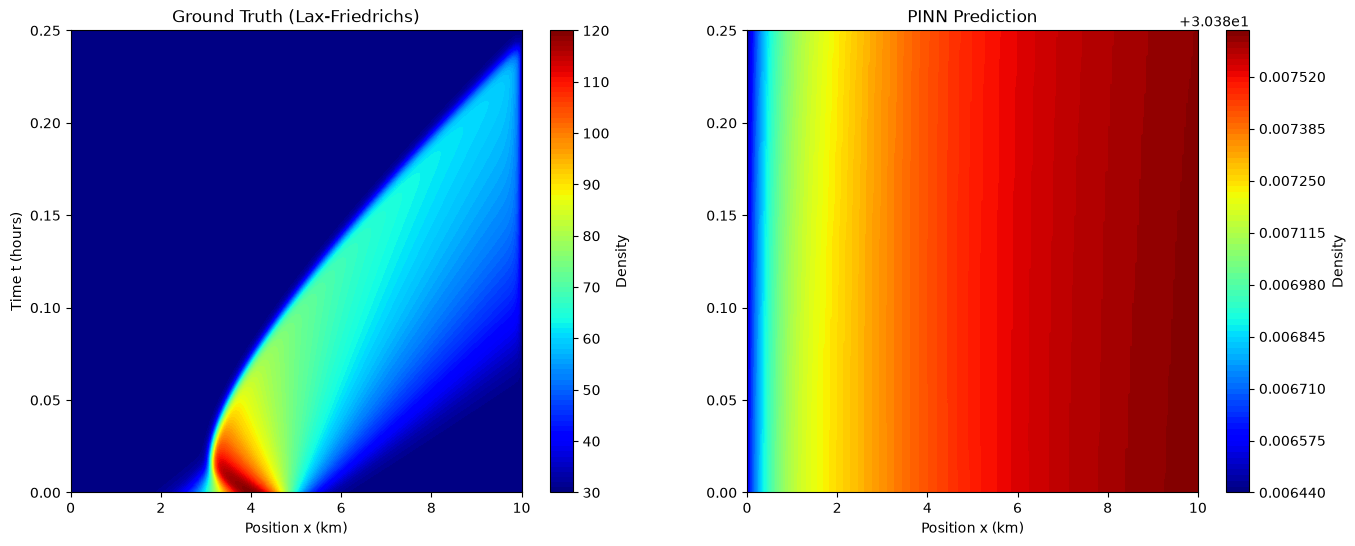

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Flatten our meshgrid coordinates to feed into the model
x_flat = X_grid.flatten()
t_flat = T_grid.flatten()

# 2. Convert to tensors and reshape to [Batch_Size, 2]
x_t_flat = np.vstack((x_flat, t_flat)).T
test_tensor = torch.tensor(x_t_flat, dtype=torch.float32)

# 3. Get predictions from the model (turn off gradient tracking for speed)
with torch.no_grad():
    pinn_pred_flat = model(test_tensor).numpy()

# 4. Reshape the flat predictions back into the 2D grid shape
rho_pinn = pinn_pred_flat.reshape(X_grid.shape)

# 5. Plot the PINN prediction side-by-side with Ground Truth
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Ground Truth
im0 = ax[0].contourf(X_grid, T_grid, rho_history, levels=100, cmap='jet')
fig.colorbar(im0, ax=ax[0], label='Density')
ax[0].set_title('Ground Truth (Lax-Friedrichs)')
ax[0].set_xlabel('Position x (km)')
ax[0].set_ylabel('Time t (hours)')

# Right Plot: PINN Prediction
im1 = ax[1].contourf(X_grid, T_grid, rho_pinn, levels=100, cmap='jet')
fig.colorbar(im1, ax=ax[1], label='Density')
ax[1].set_title('PINN Prediction')
ax[1].set_xlabel('Position x (km)')

plt.show()

In [25]:
# Scale coordinates to be between 0 and 1
x_pde_norm = x_pde / 10.0
t_pde_norm = t_pde / 0.25

# Create normalized IC coordinates
x_tensor_norm = torch.tensor(arr_x, dtype=torch.float32).unsqueeze(1) / 10.0
t_zero_tensor = torch.zeros_like(x_tensor_norm)
ic_coords_norm = torch.hstack((x_tensor_norm, t_zero_tensor))

# Create normalized BC coordinates
t_tensor_norm = torch.tensor(arr_t, dtype=torch.float32).unsqueeze(1) / 0.25
x_zero_tensor = torch.zeros_like(t_tensor_norm)
x_one_tensor = torch.ones_like(t_tensor_norm) # 10.0 / 10.0 = 1.0

bc_left_coords_norm = torch.hstack((x_zero_tensor, t_tensor_norm))
bc_right_coords_norm = torch.hstack((x_one_tensor, t_tensor_norm))

In [26]:
def compute_pde_loss_normalized(model, x_norm, t_norm):
    x_norm.requires_grad_(True)
    t_norm.requires_grad_(True)
    
    xt_input = torch.hstack((x_norm, t_norm))
    rho = model(xt_input)
    
    # Gradients with respect to normalized inputs
    drho_dt_norm = torch.autograd.grad(rho, t_norm, grad_outputs=torch.ones_like(rho), create_graph=True)[0]
    drho_dx_norm = torch.autograd.grad(rho, x_norm, grad_outputs=torch.ones_like(rho), create_graph=True)[0]
    
    # Rescale gradients back to physical space using chain rule
    drho_dt = drho_dt_norm / 0.25
    drho_dx = drho_dx_norm / 10.0
    
    v_max = 100.0
    rho_max = 150.0
    
    pde_residual = drho_dt + v_max * (1.0 - (2.0 * rho) / rho_max) * drho_dx
    return torch.mean(pde_residual ** 2)

In [27]:
# %%
# Fixed Training Loop with Dynamic Collocation Points
import torch.optim as optim

model_norm = TrafficPINN()
optimizer_norm = optim.Adam(model_norm.parameters(), lr=5e-4)

epochs_norm = 3000
loss_function = nn.MSELoss()
N_pde = 10000

print("Starting Fixed Normalized Training Loop...")
for epoch in range(epochs_norm):
    optimizer_norm.zero_grad()
    
    # --- A. Normalized IC Loss ---
    pred_rho_ic = model_norm(ic_coords_norm)
    loss_ic = loss_function(pred_rho_ic, real_rho_ic)
    
    # --- B. Normalized BC Loss ---
    pred_left = model_norm(bc_left_coords_norm)
    pred_right = model_norm(bc_right_coords_norm)
    real_bc = torch.ones_like(pred_left) * 30.0
    loss_bc = loss_function(pred_left, real_bc) + loss_function(pred_right, real_bc)
    
    # --- C. Fresh Normalized PDE Loss ---
    # We generate fresh random points EVERY epoch so the computational graph is brand new
    x_pde_dynamic = torch.rand(N_pde, 1) # [0, 1] range already matches normalized space
    t_pde_dynamic = torch.rand(N_pde, 1) # [0, 1] range already matches normalized time
    
    loss_pde = compute_pde_loss_normalized(model_norm, x_pde_dynamic, t_pde_dynamic)
    
    # --- D. Total Loss ---
    total_loss = 100 * loss_ic + 100 * loss_bc + 1.0 * loss_pde
    
    # --- E. Backpropagation ---
    total_loss.backward()
    optimizer_norm.step()
    
    # Print progress every 300 epochs
    if epoch % 300 == 0:
        print(f"Epoch {epoch:4d} | Total Loss: {total_loss.item():.4f} | IC: {loss_ic.item():.4f} | BC: {loss_bc.item():.4f} | PDE: {loss_pde.item():.4f}")

print("Normalized Training Finished Successfully!")

Starting Fixed Normalized Training Loop...
Epoch    0 | Total Loss: 465050.8125 | IC: 2857.1572 | BC: 1793.3508 | PDE: 0.0117
Epoch  300 | Total Loss: 231183.1406 | IC: 1786.8947 | BC: 524.9368 | PDE: 0.0002
Epoch  600 | Total Loss: 149869.3750 | IC: 1353.3726 | BC: 145.3213 | PDE: 0.0000
Epoch  900 | Total Loss: 112437.1562 | IC: 1108.2618 | BC: 16.1097 | PDE: 0.0000
Epoch 1200 | Total Loss: 98056.3906 | IC: 978.4369 | BC: 2.1270 | PDE: 0.0000
Epoch 1500 | Total Loss: 93738.2266 | IC: 914.8789 | BC: 22.5034 | PDE: 0.0000
Epoch 1800 | Total Loss: 92779.5234 | IC: 886.4568 | BC: 41.3384 | PDE: 0.0000
Epoch 2100 | Total Loss: 92629.9062 | IC: 875.1906 | BC: 51.1085 | PDE: 0.0000
Epoch 2400 | Total Loss: 92614.3047 | IC: 871.4124 | BC: 54.7306 | PDE: 0.0000
Epoch 2700 | Total Loss: 92613.2422 | IC: 870.3931 | BC: 55.7393 | PDE: 0.0000
Normalized Training Finished Successfully!


In [28]:
# %%
# Step 8: Pre-training Phase + Physics Phase
import torch.optim as optim

# 1. Fresh model instance
model_pretrain = TrafficPINN()

# 2. Phase 1: Heavy Adam Optimizer focused ONLY on Data (IC/BC)
optimizer_phase1 = optim.Adam(model_pretrain.parameters(), lr=1e-3)
epochs_phase1 = 1500

print("--- Phase 1: Pre-training on Initial & Boundary Conditions ---")
for epoch in range(epochs_phase1):
    optimizer_phase1.zero_grad()
    
    # Calculate IC and BC errors
    pred_rho_ic = model_pretrain(ic_coords_norm)
    loss_ic = loss_function(pred_rho_ic, real_rho_ic)
    
    pred_left = model_pretrain(bc_left_coords_norm)
    pred_right = model_pretrain(bc_right_coords_norm)
    real_bc = torch.ones_like(pred_left) * 30.0
    loss_bc = loss_function(pred_left, real_bc) + loss_function(pred_right, real_bc)
    
    # Total Data Loss (NO PHYSICS YET)
    total_data_loss = loss_ic + loss_bc
    
    total_data_loss.backward()
    optimizer_phase1.step()
    
    if epoch % 300 == 0:
        print(f"Pre-train Epoch {epoch:4d} | Data Loss: {total_data_loss.item():.4f} | IC: {loss_ic.item():.4f} | BC: {loss_bc.item():.4f}")

# 3. Phase 2: Introduce Physics Loss with a lower learning rate to preserve the shape
optimizer_phase2 = optim.Adam(model_pretrain.parameters(), lr=2e-4)
epochs_phase2 = 2000

print("\n--- Phase 2: Activating Normalized Physics Loss ---")
for epoch in range(epochs_phase2):
    optimizer_phase2.zero_grad()
    
    pred_rho_ic = model_pretrain(ic_coords_norm)
    loss_ic = loss_function(pred_rho_ic, real_rho_ic)
    
    pred_left = model_pretrain(bc_left_coords_norm)
    pred_right = model_pretrain(bc_right_coords_norm)
    loss_bc = loss_function(pred_left, real_bc) + loss_function(pred_right, real_bc)
    
    # Generate fresh points for the PDE graph
    x_pde_dynamic = torch.rand(N_pde, 1)
    t_pde_dynamic = torch.rand(N_pde, 1)
    loss_pde = compute_pde_loss_normalized(model_pretrain, x_pde_dynamic, t_pde_dynamic)
    
    # Balanced loss now that the network already knows the initial layout
    total_loss = 1.0 * loss_ic + 1.0 * loss_bc + 1.0 * loss_pde
    
    total_loss.backward()
    optimizer_phase2.step()
    
    if epoch % 400 == 0:
        print(f"Physics Epoch {epoch:4d} | Total: {total_loss.item():.4f} | IC: {loss_ic.item():.4f} | BC: {loss_bc.item():.4f} | PDE: {loss_pde.item():.4f}")

--- Phase 1: Pre-training on Initial & Boundary Conditions ---
Pre-train Epoch    0 | Data Loss: 4669.3618 | IC: 2866.2783 | BC: 1803.0836
Pre-train Epoch  300 | Data Loss: 1460.7188 | IC: 1330.8536 | BC: 129.8651
Pre-train Epoch  600 | Data Loss: 976.5994 | IC: 973.7701 | BC: 2.8293
Pre-train Epoch  900 | Data Loss: 928.1056 | IC: 887.9648 | BC: 40.1408
Pre-train Epoch 1200 | Data Loss: 926.1613 | IC: 872.2145 | BC: 53.9468

--- Phase 2: Activating Normalized Physics Loss ---
Physics Epoch    0 | Total: 926.1326 | IC: 870.2882 | BC: 55.8444 | PDE: 0.0000
Physics Epoch  400 | Total: 839.9222 | IC: 782.3961 | BC: 45.5536 | PDE: 11.9725
Physics Epoch  800 | Total: 670.6845 | IC: 592.9755 | BC: 66.8335 | PDE: 10.8755
Physics Epoch 1200 | Total: 650.0431 | IC: 554.3385 | BC: 80.7649 | PDE: 14.9397
Physics Epoch 1600 | Total: 639.9783 | IC: 537.3864 | BC: 88.0506 | PDE: 14.5414


In [29]:
# %%
# Step 9: SIREN (Sinusoidal Representation Network) Architecture
import torch
import torch.nn as nn
import numpy as np

class TrafficSIREN(nn.Module):
    def __init__(self):
        super(TrafficSIREN, self).__init__()
        
        # Define layers exactly like before
        self.input_layer = nn.Linear(2, 64)
        self.hidden1 = nn.Linear(64, 64)
        self.hidden2 = nn.Linear(64, 64)
        self.hidden3 = nn.Linear(64, 64)
        self.output_layer = nn.Linear(64, 1)
        
        # Custom Weight Initialization for Sinusoidal Activations
        # This is critical so that the gradients don't vanish or explode
        with torch.no_grad():
            # First layer needs a scaling factor (w0 = 30 is standard for spatial details)
            w0 = 30.0
            self.input_layer.weight.uniform_(-1.0 / 2.0, 1.0 / 2.0)
            self.input_layer.weight.mul_(w0)
            
            # Hidden layers initialization
            for layer in [self.hidden1, self.hidden2, self.hidden3]:
                layer.weight.uniform_(-np.sqrt(6.0 / 64.0) / w0, np.sqrt(6.0 / 64.0) / w0)
                
    def forward(self, x_and_t):
        # Pass through layers using torch.sin instead of nn.Tanh()
        out = torch.sin(self.input_layer(x_and_t))
        out = torch.sin(self.hidden1(out))
        out = torch.sin(self.hidden2(out))
        out = torch.sin(self.hidden3(out))
        
        # Output layer (no activation function)
        rho_prediction = self.output_layer(out)
        return rho_prediction

In [30]:
# %%
# Step 9.2: Isolated SIREN Setup Verification
import torch
import torch.nn as nn
import numpy as np

class TrafficSIREN(nn.Module):
    def __init__(self):
        super(TrafficSIREN, self).__init__()
        
        self.input_layer = nn.Linear(2, 64)
        self.hidden1 = nn.Linear(64, 64)
        self.hidden2 = nn.Linear(64, 64)
        self.hidden3 = nn.Linear(64, 64)
        self.output_layer = nn.Linear(64, 1)
        
        # Explicit initialization with explicit boundaries
        with torch.no_grad():
            w0 = 30.0
            # Scale first layer
            self.input_layer.weight.uniform_(-1.0 / 2.0, 1.0 / 2.0)
            self.input_layer.weight.mul_(w0)
            self.input_layer.bias.uniform_(-1.0 / 2.0, 1.0 / 2.0)
            
            # Scale remaining hidden layers
            hidden_bound = np.sqrt(6.0 / 64.0) / w0
            for layer in [self.hidden1, self.hidden2, self.hidden3]:
                layer.weight.uniform_(-hidden_bound, hidden_bound)
                layer.bias.uniform_(-hidden_bound, hidden_bound)
                
    def forward(self, x_and_t):
        out = torch.sin(self.input_layer(x_and_t))
        out = torch.sin(self.hidden1(out))
        out = torch.sin(self.hidden2(out))
        out = torch.sin(self.hidden3(out))
        return self.output_layer(out)

# Instantiate the model right now to check if it chokes
try:
    model_siren = TrafficSIREN()
    print("SUCCESS: SIREN Model instantiated and initialized properly.")
    print(model_siren)
except Exception as e:
    print(f"FAILED during initialization: {e}")

SUCCESS: SIREN Model instantiated and initialized properly.
TrafficSIREN(
  (input_layer): Linear(in_features=2, out_features=64, bias=True)
  (hidden1): Linear(in_features=64, out_features=64, bias=True)
  (hidden2): Linear(in_features=64, out_features=64, bias=True)
  (hidden3): Linear(in_features=64, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [31]:
# %%
# Step 9.3: Simplified SIREN Pre-training Phase
import torch.optim as optim

optimizer_siren = optim.Adam(model_siren.parameters(), lr=1e-3)
epochs_p1 = 1500
loss_function = nn.MSELoss()

print("--- Launching Isolated SIREN Pre-training Loop ---")
for epoch in range(epochs_p1):
    optimizer_siren.zero_grad()
    
    # 1. Forward pass on normalized Initial Conditions
    pred_rho_ic = model_siren(ic_coords_norm)
    loss_ic = loss_function(pred_rho_ic, real_rho_ic)
    
    # 2. Forward pass on normalized Boundary Conditions
    pred_left = model_siren(bc_left_coords_norm)
    pred_right = model_siren(bc_right_coords_norm)
    real_bc = torch.ones_like(pred_left) * 30.0
    loss_bc = loss_function(pred_left, real_bc) + loss_function(pred_right, real_bc)
    
    # 3. Sum data targets
    total_data_loss = loss_ic + loss_bc
    
    # 4. Backward execution
    total_data_loss.backward()
    optimizer_siren.step()
    
    # Print status updates explicitly
    if epoch % 300 == 0:
        print(f"Epoch {epoch:4d} | Data Loss: {total_data_loss.item():.4f} | IC Loss: {loss_ic.item():.4f} | BC Loss: {loss_bc.item():.4f}")

print("Pre-training execution successfully concluded.")

--- Launching Isolated SIREN Pre-training Loop ---
Epoch    0 | Data Loss: 4685.7866 | IC Loss: 2872.5562 | BC Loss: 1813.2305
Epoch  300 | Data Loss: 1409.1714 | IC Loss: 1299.6702 | BC Loss: 109.5012
Epoch  600 | Data Loss: 966.1671 | IC Loss: 960.8523 | BC Loss: 5.3148
Epoch  900 | Data Loss: 785.8137 | IC Loss: 785.5898 | BC Loss: 0.2239
Epoch 1200 | Data Loss: 605.2946 | IC Loss: 605.1562 | BC Loss: 0.1385
Pre-training execution successfully concluded.


In [32]:
# %%
# Step 9.4: SIREN Physics Integration Phase
import torch.optim as optim

optimizer_siren_p2 = optim.Adam(model_siren.parameters(), lr=2e-4)
epochs_p2 = 2000
N_pde = 10000

print("--- Launching Full SIREN Physics Integration Loop ---")
for epoch in range(epochs_p2):
    optimizer_siren_p2.zero_grad()
    
    # 1. Normalized IC Loss
    pred_rho_ic = model_siren(ic_coords_norm)
    loss_ic = loss_function(pred_rho_ic, real_rho_ic)
    
    # 2. Normalized BC Loss
    pred_left = model_siren(bc_left_coords_norm)
    pred_right = model_siren(bc_right_coords_norm)
    real_bc = torch.ones_like(pred_left) * 30.0
    loss_bc = loss_function(pred_left, real_bc) + loss_function(pred_right, real_bc)
    
    # 3. Dynamic Normalized PDE Loss
    x_pde_dynamic = torch.rand(N_pde, 1)
    t_pde_dynamic = torch.rand(N_pde, 1)
    loss_pde = compute_pde_loss_normalized(model_siren, x_pde_dynamic, t_pde_dynamic)
    
    # 4. Total Balanced Loss
    total_loss = 1.0 * loss_ic + 1.0 * loss_bc + 1.0 * loss_pde
    
    # 5. Backward Pass
    total_loss.backward()
    optimizer_siren_p2.step()
    
    # Print status updates explicitly
    if epoch % 400 == 0:
        print(f"Epoch {epoch:4d} | Total: {total_loss.item():.4f} | IC: {loss_ic.item():.4f} | BC: {loss_bc.item():.4f} | PDE: {loss_pde.item():.4f}")

print("SIREN Physics Training Finished Successfully!")

--- Launching Full SIREN Physics Integration Loop ---
Epoch    0 | Total: 4955722.5000 | IC: 449.4853 | BC: 0.0436 | PDE: 4955273.0000
Epoch  400 | Total: 18620.2305 | IC: 1905.6282 | BC: 988.1980 | PDE: 15726.4053
Epoch  800 | Total: 7069.8770 | IC: 2129.9182 | BC: 1062.7344 | PDE: 3877.2241
Epoch 1200 | Total: 5004.2271 | IC: 2165.0056 | BC: 1077.1012 | PDE: 1762.1200
Epoch 1600 | Total: 4319.5918 | IC: 2153.6584 | BC: 1077.2910 | PDE: 1088.6425
SIREN Physics Training Finished Successfully!


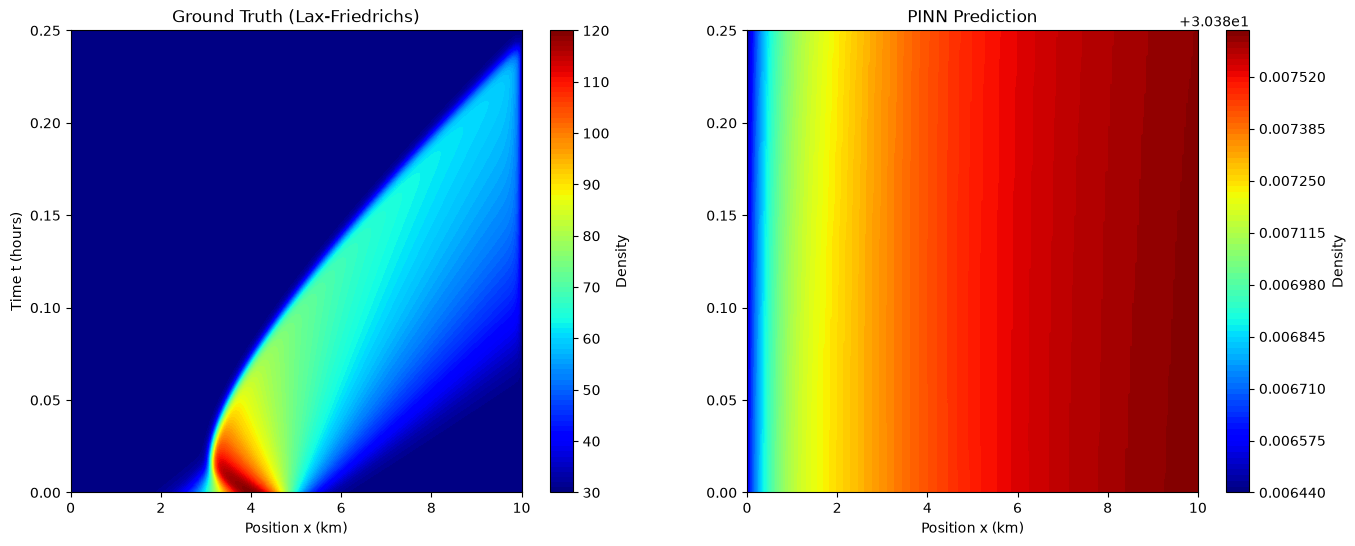

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Flatten our meshgrid coordinates to feed into the model
x_flat = X_grid.flatten()
t_flat = T_grid.flatten()

# 2. Convert to tensors and reshape to [Batch_Size, 2]
x_t_flat = np.vstack((x_flat, t_flat)).T
test_tensor = torch.tensor(x_t_flat, dtype=torch.float32)

# 3. Get predictions from the model (turn off gradient tracking for speed)
with torch.no_grad():
    pinn_pred_flat = model(test_tensor).numpy()

# 4. Reshape the flat predictions back into the 2D grid shape
rho_pinn = pinn_pred_flat.reshape(X_grid.shape)

# 5. Plot the PINN prediction side-by-side with Ground Truth
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Ground Truth
im0 = ax[0].contourf(X_grid, T_grid, rho_history, levels=100, cmap='jet')
fig.colorbar(im0, ax=ax[0], label='Density')
ax[0].set_title('Ground Truth (Lax-Friedrichs)')
ax[0].set_xlabel('Position x (km)')
ax[0].set_ylabel('Time t (hours)')

# Right Plot: PINN Prediction
im1 = ax[1].contourf(X_grid, T_grid, rho_pinn, levels=100, cmap='jet')
fig.colorbar(im1, ax=ax[1], label='Density')
ax[1].set_title('PINN Prediction')
ax[1].set_xlabel('Position x (km)')

plt.show()